# Transparency Mode With LLM Interaction beyond ChatGPT and ChatBot

In [3]:
from http.client import responses

print("Test")

Test


In [5]:
import tiktoken

tokenizer = tiktoken.encoding_for_model("gpt-4o")

In [6]:
print(tokenizer.name)

o200k_base


In [7]:
prompt = "Vous etes un expert en IA Agentique, C'est quoi un agent AI"

In [8]:
tokens = tokenizer.encode(prompt)

In [9]:
print(tokens)

[29038, 859, 268, 537, 8333, 469, 59199, 28237, 2222, 11, 363, 6616, 33399, 537, 11793, 20837]


In [10]:
print(len(tokens))

16


In [11]:
for token in tokens:
    #print(tokenizer.decode([token]))
    t = tokenizer.decode_single_token_bytes(token).decode("utf-8")
    print(t, end="|")

# Equivalent on OpenAI API: https://platform.openai.com/tokenizer

Vous| et|es| un| expert| en| IA| Agent|ique|,| C|'est| quoi| un| agent| AI|

In [18]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [48]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)

from langchain.messages import SystemMessage, HumanMessage, AIMessage

In [49]:
response = llm.invoke(input=[
    {"role": "system", "content": "Vous etes un expert en IA Agentique."}, # premiere phrase d'instruction est le personnage(persona) de l'agent, c'est lui qui va guider la reponse de l'agent
    {"role": "user", "content": "C'est quoi un agent AI ?"},
])

In [51]:
response = llm.invoke(input=[
    SystemMessage("Vous etes un expert en IA Agentique."),
    HumanMessage("C'est quoi un agent AI ?"),
])

In [52]:
print(response.content)

Un agent AI (ou agent intelligent) est une entité autonome qui perçoit son environnement à travers des capteurs, prend des décisions ou effectue des actions pour atteindre des objectifs spécifiques. Ces agents peuvent être logiciels ou matériels et sont conçus pour simuler des aspects de l'intelligence humaine, tels que la perception, la raisonnement, l'apprentissage et la prise de décision.

Les agents AI peuvent être classés en plusieurs catégories en fonction de leur complexité et de leurs capacités :

1. **Agents réactifs simples** : Ils agissent uniquement en réponse à des stimuli de l'environnement, sans conserver d'historique des perceptions passées. Ils suivent des règles prédéfinies pour réagir à des situations spécifiques.

2. **Agents basés sur des modèles** : Ils maintiennent un modèle interne de l'état du monde, ce qui leur permet de gérer des environnements partiellement observables et de planifier des actions futures.

3. **Agents basés sur des objectifs** : En plus de m

In [53]:
from IPython.display import Markdown

In [55]:
print(display(Markdown(response.content)))

Un agent AI (ou agent intelligent) est une entité autonome qui perçoit son environnement à travers des capteurs, prend des décisions ou effectue des actions pour atteindre des objectifs spécifiques. Ces agents peuvent être logiciels ou matériels et sont conçus pour simuler des aspects de l'intelligence humaine, tels que la perception, la raisonnement, l'apprentissage et la prise de décision.

Les agents AI peuvent être classés en plusieurs catégories en fonction de leur complexité et de leurs capacités :

1. **Agents réactifs simples** : Ils agissent uniquement en réponse à des stimuli de l'environnement, sans conserver d'historique des perceptions passées. Ils suivent des règles prédéfinies pour réagir à des situations spécifiques.

2. **Agents basés sur des modèles** : Ils maintiennent un modèle interne de l'état du monde, ce qui leur permet de gérer des environnements partiellement observables et de planifier des actions futures.

3. **Agents basés sur des objectifs** : En plus de maintenir un modèle du monde, ces agents ont des objectifs spécifiques qu'ils essaient d'atteindre. Ils évaluent différentes actions possibles en fonction de leur capacité à atteindre ces objectifs.

4. **Agents basés sur l'utilité** : Ils choisissent des actions en fonction d'une fonction d'utilité qui évalue le degré de satisfaction des objectifs. Cela leur permet de gérer des situations où plusieurs objectifs peuvent être en conflit.

5. **Agents d'apprentissage** : Ces agents améliorent leurs performances au fil du temps en apprenant de leurs expériences passées. Ils utilisent des techniques d'apprentissage automatique pour adapter leur comportement en fonction des résultats de leurs actions précédentes.

Les agents AI sont utilisés dans de nombreux domaines, tels que les assistants virtuels, les systèmes de recommandation, les jeux vidéo, la robotique, et bien d'autres applications où l'autonomie et l'intelligence sont nécessaires.

None


## Test LLM With Postman/Bruno
- Public LLM like OpenAI API, HuggingFace Inference API, etc
<img src="images/llm_api.png" alt="LLM API" width="600"/>

- Local LLM with Ollama like Llama2, Falcon, etc
```shell
ollama serve

ollama ls
NAME                    ID              SIZE      MODIFIED
gemma3:1b               8648f39daa8f    815 MB    43 seconds ago
qwen3-coder:30b         06c1097efce0    18 GB     5 days ago
gpt-oss:20b             17052f91a42e    13 GB     2 weeks ago
glm-4.7-flash:latest    d1a8a26252f1    19 GB     2 weeks ago

ollama run qwen3-coder:30b
```

<img src="images/llm_ollama.png" alt="LLM Olama" width="600"/>

In [27]:
from langchain_ollama import ChatOllama

In [30]:
llm2 = ChatOllama(model="gemma3:1b", temperature=0)

In [35]:
response2 = llm2.invoke(input=[
    {"role": "system", "content": "Vous etes un expert en IA Agentique."}, # premiere phrase d'instruction est le personnage(persona) de l'agent, c'est lui qui va guider la reponse de l'agent
    {"role": "user", "content": "C'est quoi un agent AI ?"},
])

In [36]:
print(display(Markdown(response2.content)))

En tant qu'expert en IA Agentique, je peux vous expliquer ce qu'est un agent AI de manière claire et détaillée. Voici une décomposition de ce qu'est un agent AI, en décomposant les concepts clés :

**1. Qu'est-ce qu'un Agent ?**

Avant de parler d'AI, il est important de comprendre ce qu'est un agent. En termes simples, un agent est un **système qui peut percevoir son environnement, prendre des décisions et agir sur cet environnement pour atteindre un objectif.**  Il est fondamentalement un "acteur" dans un système.  Pensez à un robot, un programme informatique, un humain, ou même un système complexe comme un marché boursier.

**2. L'IA Agentique : Une Approche Plus Sophistiquée**

L'IA Agentique est une branche de l'IA qui se concentre sur la création d'agents intelligents capables de **développer et d'adapter leur propre comportement et leurs objectifs au fil du temps, en se basant sur l'expérience et l'apprentissage.**  Elle va au-delà de la simple automatisation et introduit une dimension de **cognition et d'auto-adaptation**.

**3. Les Caractéristiques Clés d'un Agent AI :**

* **Perception :** L'agent doit être capable de "voir" et de "comprendre" son environnement. Cela implique l'utilisation de capteurs (images, sons, données) et de techniques d'analyse pour extraire des informations pertinentes.
* **Planification :** L'agent doit être capable de définir des objectifs et de créer des plans d'action pour atteindre ces objectifs.  Il utilise souvent des algorithmes de planification comme l'algorithme de Dijkstra ou des techniques d'optimisation.
* **Action :** L'agent doit être capable d'agir sur son environnement. Cela peut être de modifier l'environnement, interagir avec d'autres agents, ou effectuer des tâches spécifiques.
* **Apprentissage :** C'est l'élément crucial. Les agents AI sont conçus pour apprendre à partir de leurs expériences. Ils peuvent utiliser des techniques d'apprentissage par renforcement, d'apprentissage supervisé ou d'apprentissage non supervisé pour s'améliorer au fil du temps.
* **Auto-Adaptation :**  C'est la capacité d'un agent à ajuster ses stratégies et ses objectifs en fonction de l'évolution de son environnement.  C'est ce qui permet à un agent de devenir plus efficace et adaptable.

**4. L'IA Agentique vs. l'IA Traditionnelle**

| Caractéristique       | IA Traditionnelle | IA Agentique |
|-----------------------|--------------------|-----------------|
| **Objectif**           | Résoudre un problème spécifique | Développer un comportement autonome et adaptable |
| **Conscience**        | Absence             | Présente (en partie) |
| **Apprentissage**      | Basé sur des données | Basé sur l'expérience et l'apprentissage |
| **Flexibilité**       | Limitée             | Très élevée     |


**5. Exemples d'Applications de l'IA Agentique**

* **Robots autonomes :**  Des robots qui peuvent naviguer dans un environnement complexe, planifier des tâches et s'adapter aux changements.
* **Systèmes de recommandation :**  Des systèmes qui ne se limitent pas à recommander des produits basés sur des données passées, mais qui apprennent les préférences des utilisateurs et s'adaptent à leurs goûts.
* **Gestion de l'énergie :**  Des systèmes qui optimisent la consommation d'énergie en apprenant les habitudes des utilisateurs et en ajustant les paramètres en temps réel.
* **Gestion de la chaîne d'approvisionnement :**  Des agents qui peuvent anticiper les problèmes et optimiser les processus pour améliorer l'efficacité.
* **Simulation et jeux :**  Des agents qui peuvent simuler des environnements complexes et apprendre à jouer à des jeux.

**6. Technologies Clés Utilisées dans l'IA Agentique**

* **Reinforcement Learning (Apprentissage par Renforcement):**  L'agent apprend en interagissant avec son environnement et en recevant des récompenses ou des pénalités.
* **Deep Learning:**  Utilisé pour l'apprentissage de modèles complexes et pour la perception de l'environnement.
* **Knowledge Representation & Reasoning:**  Permet aux agents de stocker et de manipuler des connaissances pour prendre des décisions.
* **Agent Frameworks (e.g., OpenAI Gym, PyTorch):**  Fournissent des environnements et des algorithmes pour permettre aux agents d'expérimenter et d'apprendre.

**En résumé, l'IA Agentique est une approche plus avancée de l'IA qui vise à créer des agents capables de s'adapter, d'apprendre et de prendre des décisions de manière autonome, ce qui les rend plus flexibles et plus efficaces dans des environnements complexes.**

**Pour aller plus loin, vous pouvez me poser des questions plus spécifiques, par exemple :**

*   Pouvez-vous me donner des exemples concrets d'applications d'IA Agentique ?
*   Qu'est-ce qui rend l'apprentissage par renforcement particulièrement important dans ce domaine ?
*   Comment l'IA Agentique se distingue-t-elle de l'IA traditionnelle ?

None


In [39]:
llm3 = ChatOpenAI(model="gpt-5.2", temperature=0.5)
llm_with_tools = llm3.bind_tools(tools=[
    {"type": "image_generation", "quality": "high", "size": "1024x1024"}
])

In [40]:
image_resp = llm_with_tools.invoke(input=[
    {"role": "user", "content": "Je veux une image d'un lifelong learner entre de se perfectionner ?"},
])

In [42]:
from IPython.display import Image
import base64

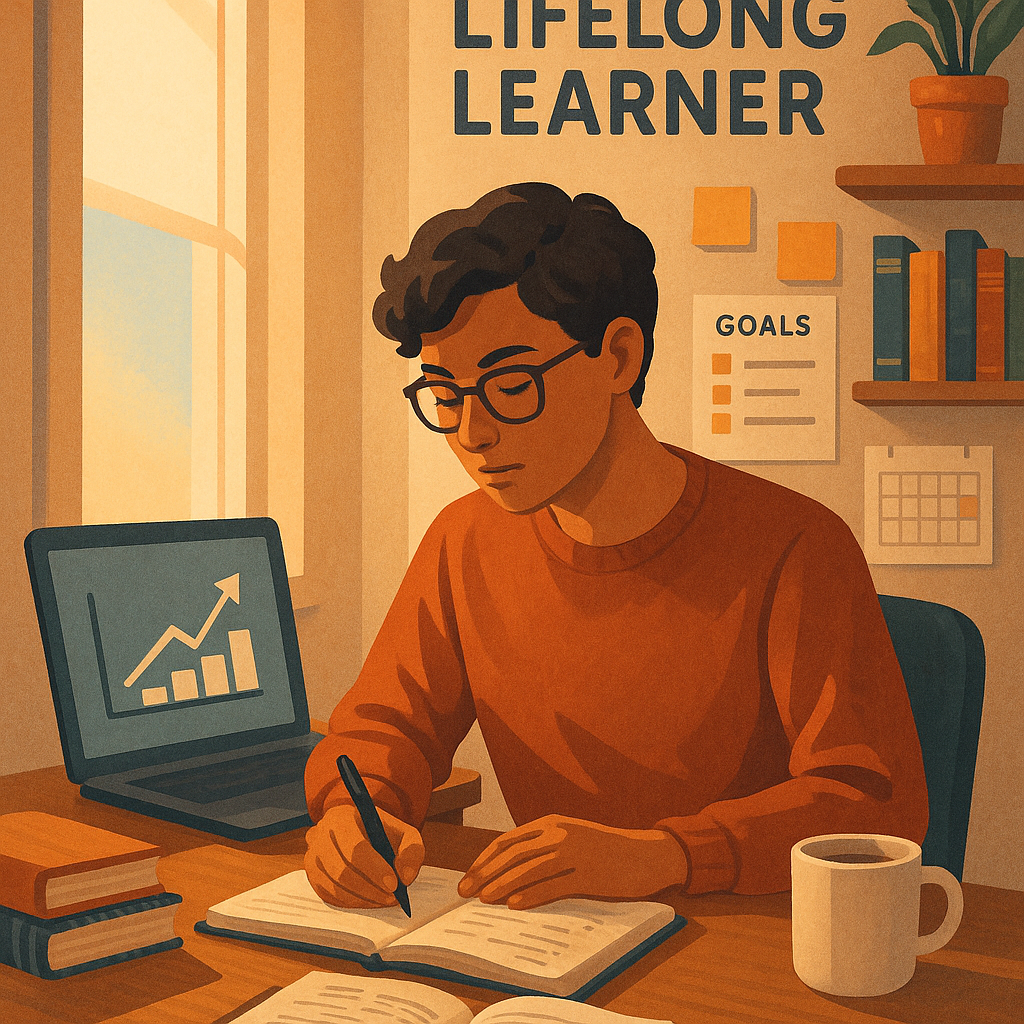

In [43]:
Image(base64.b64decode(image_resp.content_blocks[0]['base64']))

In [44]:
path = "images/RAG-process.png"

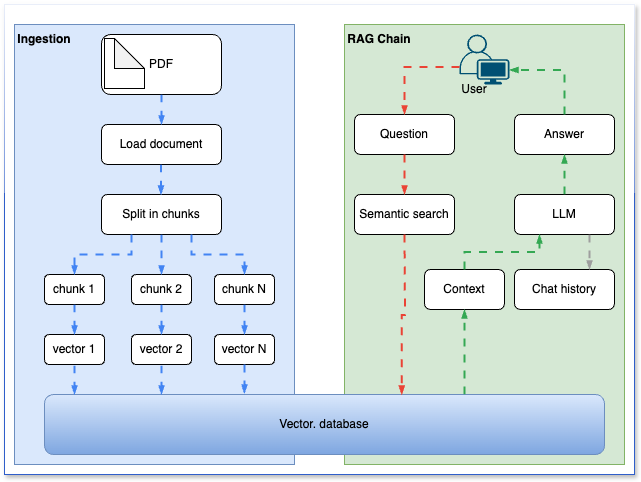

In [45]:
Image(path)

In [57]:
llm4 = ChatOpenAI(model="gpt-5.2", temperature=0.5)

In [59]:
with open(path, "rb") as file:
    image = base64.b64encode(file.read()).decode("utf-8")

In [60]:
resp = llm4.invoke(input=[
    HumanMessage(content=[
        {"type": "text", "text":"Explique moi ce que tu vois dans cette image."},
        {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{image}"}}, # https://www.base64-image.de
    ]),
])

In [61]:
print(display(Markdown(resp.content)))

L’image illustre une architecture **RAG (Retrieval-Augmented Generation)**, découpée en deux grandes phases, avec une **base de données vectorielle** en bas qui sert de pont entre les deux.

## 1) Partie gauche : *Ingestion* (préparation des documents)
On part d’un **PDF** :
1. **Load document** : le document est chargé.
2. **Split in chunks** : il est **découpé en morceaux** (“chunks”).
3. Chaque chunk est transformé en **vecteur** (embedding) : *chunk 1 → vector 1*, *chunk 2 → vector 2*, etc.
4. Tous ces vecteurs sont stockés dans la **Vector database**.

But : rendre le contenu du PDF “recherchable” via des similarités sémantiques.

## 2) Partie droite : *RAG Chain* (question → recherche → réponse)
Côté utilisation :
1. L’**utilisateur** pose une **Question**.
2. La question déclenche une **Semantic search** (recherche sémantique) dans la **base vectorielle** pour retrouver les chunks les plus pertinents.
3. Les passages retrouvés sont assemblés en **Context** (contexte).
4. Le **LLM** (modèle de langage) reçoit :
   - le **Context** (résultats récupérés),
   - éventuellement le **Chat history** (historique de conversation),
   puis génère une **Answer** renvoyée à l’utilisateur.

## 3) Sens des flèches / logique
- Les flèches de gauche montrent le **pipeline d’indexation** (du PDF vers des vecteurs stockés).
- Les flèches de droite montrent le **pipeline de réponse** (question → récupération de contexte → génération par le LLM).
- La **Vector database** est le composant central : elle sert à **retrouver** l’information pertinente au moment de répondre.

None


In [100]:
system_message = """
Tu es un analyste en intelligence strategique IT/IA. Analyse le texte fourni selon les dimensions geopolitique, economique et technologique.
Identifie pour chaque dimension : la polarite (negatif/neutre/positif), la tonalite, les acteurs, l'horizon temporel et le niveau d'impact IT/IA (faible/modere/fort/critique).
Detecte les signaux faibles et formule des recommandations de veille concretes.
Retourne UNIQUEMENT un JSON valide, sans markdown ni backticks, a un seul niveau d'imbrication.
Champs obligatoires sans accents : "resume_executif", "tableau_sentiments", "impact_it_ia", "signaux_faibles_it_ia", "recommandations_veille".
"""

In [101]:
llm5 = ChatOpenAI(model="gpt-5.2")

In [102]:
response = llm5.invoke(input=[
    SystemMessage(system_message),
    HumanMessage("""L'IA agentique représente une rupture structurelle pour le secteur IT mondial. Microsoft, Google et Salesforce accélèrent les agents autonomes (+30-40% productivité). Les ESN peinent à se repositionner. La France, l'Allemagne et l'Inde s'inquiètent de la souveraineté des données. La Chine investit dans ses propres architectures agentiques (ERNIE, Qwen). Certains analystes parlent de "vassalisation numérique", d'autres voient une opportunité pour les acteurs mid-market spécialisés conformité.
    """),
])

In [103]:
print(response.content)

{
  "resume_executif": "Le texte décrit l'IA agentique comme une rupture majeure pour l'IT mondial, portée par les hyperscalers (Microsoft, Google, Salesforce) avec des gains de productivite annonces de 30-40%. Cette acceleration fragilise les ESN qui peinent a se repositionner. Sur le plan geopolitique, les enjeux de souverainete des donnees montent en France, Allemagne et Inde, tandis que la Chine pousse des alternatives domestiques (ERNIE, Qwen). Le debat se polarise entre risque de dependance (\"vassalisation numerique\") et opportunite pour des acteurs mid-market specialises en conformite, ouvrant un espace de marche pour des solutions souveraines, gouvernance, et outillage d'audit/controle des agents.",
  "tableau_sentiments": {
    "geopolitique": {
      "polarite": "negatif",
      "tonalite": "inquietude, rivalite, souverainete, dependance strategique",
      "acteurs": "France; Allemagne; Inde; Chine; (implicitement) Etats-Unis via Microsoft/Google/Salesforce; regulateurs na

In [107]:
import json
parsed = json.loads(response.content)
print(parsed)

{'resume_executif': 'Le texte décrit l\'IA agentique comme une rupture majeure pour l\'IT mondial, portée par les hyperscalers (Microsoft, Google, Salesforce) avec des gains de productivite annonces de 30-40%. Cette acceleration fragilise les ESN qui peinent a se repositionner. Sur le plan geopolitique, les enjeux de souverainete des donnees montent en France, Allemagne et Inde, tandis que la Chine pousse des alternatives domestiques (ERNIE, Qwen). Le debat se polarise entre risque de dependance ("vassalisation numerique") et opportunite pour des acteurs mid-market specialises en conformite, ouvrant un espace de marche pour des solutions souveraines, gouvernance, et outillage d\'audit/controle des agents.', 'tableau_sentiments': {'geopolitique': {'polarite': 'negatif', 'tonalite': 'inquietude, rivalite, souverainete, dependance strategique', 'acteurs': 'France; Allemagne; Inde; Chine; (implicitement) Etats-Unis via Microsoft/Google/Salesforce; regulateurs nationaux et europeens', 'hori

In [108]:
print(parsed['resume_executif'])

Le texte décrit l'IA agentique comme une rupture majeure pour l'IT mondial, portée par les hyperscalers (Microsoft, Google, Salesforce) avec des gains de productivite annonces de 30-40%. Cette acceleration fragilise les ESN qui peinent a se repositionner. Sur le plan geopolitique, les enjeux de souverainete des donnees montent en France, Allemagne et Inde, tandis que la Chine pousse des alternatives domestiques (ERNIE, Qwen). Le debat se polarise entre risque de dependance ("vassalisation numerique") et opportunite pour des acteurs mid-market specialises en conformite, ouvrant un espace de marche pour des solutions souveraines, gouvernance, et outillage d'audit/controle des agents.
